In [49]:
# 1. imports
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import matplotlib.pyplot as plt
import torch.optim as optim
import os
from PIL import Image
from torchvision import transforms
from sklearn.model_selection import train_test_split
import shutil
# 2. device
# 3. dataset + dataloader
# 4. model
# 5. loss
# 6. optimizer
# 7. training loop
# 8. validation loop


In [38]:
# 2. device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [39]:
#creating a function to extract the same dataset but with only 100 images per class
os.listdir(r"D:\Datasets\Kaggle\CIFAR10\cifar10\train")
#creating a subset for overfitting
def create_subset(source, target,limit=100):
    classes = [c for c in os.listdir(source) if os.path.isdir(os.path.join(source, c))]
    for class_name in classes:
        source_path = os.path.join(source, class_name)
        target_path = os.path.join(target, class_name)
        os.makedirs(target_path, exist_ok=True)

        all_images = os.listdir(source_path)
        subset_images = all_images[:limit]

        for image_name in subset_images:
            source_file = os.path.join(source_path, image_name)
            target_file = os.path.join(target_path, image_name)

            shutil.copy(source_file, target_file)
        
        print("Copying done!!!!!!!!!!!!!!!!!!!!!!!")

source = r"D:\Datasets\Kaggle\CIFAR10\cifar10\train"
target = r"C:\Coding\Python learnen materials\Projects\Newb2ProRoadmap\CIFAR10\subset"
create_subset(source, target)

Copying done!!!!!!!!!!!!!!!!!!!!!!!
Copying done!!!!!!!!!!!!!!!!!!!!!!!
Copying done!!!!!!!!!!!!!!!!!!!!!!!
Copying done!!!!!!!!!!!!!!!!!!!!!!!
Copying done!!!!!!!!!!!!!!!!!!!!!!!
Copying done!!!!!!!!!!!!!!!!!!!!!!!
Copying done!!!!!!!!!!!!!!!!!!!!!!!
Copying done!!!!!!!!!!!!!!!!!!!!!!!
Copying done!!!!!!!!!!!!!!!!!!!!!!!
Copying done!!!!!!!!!!!!!!!!!!!!!!!


In [40]:
# 3. dataset + dataloader

labels_path = os.path.join(r"D:\Datasets\Kaggle\CIFAR10\cifar10", "labels.txt")
train_dir = os.path.join(r"C:\Coding\Python learnen materials\Projects\Newb2ProRoadmap\CIFAR10", "subset")
test_dir = os.path.join(r"D:\Datasets\Kaggle\CIFAR10\cifar10", "test")

with open(labels_path,"r", encoding="utf-8") as f:
    labels = [line.strip() for line in f if line.strip()]
print(labels)

rows = []
for label in labels:
    folder = os.path.join(train_dir, label)

    if not os.path.isdir(folder):
        print("Missing folder:", folder)
        continue
    
    for filename in os.listdir(folder):
        full_path = os.path.join(folder,filename)

        if os.path.isfile(full_path):
            rows.append({"label" : label, "path" : full_path})

df = pd.DataFrame(rows)
print(df.head())
print("Total training images = ", len(df))

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
      label                                               path
0  airplane  C:\Coding\Python learnen materials\Projects\Ne...
1  airplane  C:\Coding\Python learnen materials\Projects\Ne...
2  airplane  C:\Coding\Python learnen materials\Projects\Ne...
3  airplane  C:\Coding\Python learnen materials\Projects\Ne...
4  airplane  C:\Coding\Python learnen materials\Projects\Ne...
Total training images =  1000


In [41]:
transform = transforms.Compose([
    transforms.Resize((32,32)),
      transforms.ToTensor(),
      transforms.Normalize((0.5,0.5,0.5),
                           (0.5,0.5,0.5))
      ])

#splitting train data to create some val data
train_df, val_df = train_test_split(df, test_size=0.1, random_state=42, stratify=df["label"])


In [42]:
class CIFARDataset(Dataset):
    def __init__(self, df, transform = None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        #mapping the labels to integers
        self.classes = sorted(self.df["label"].unique())
        self.classes_to_idx = {c:i for i,c in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        path = self.df.loc[idx, "path"]
        label_str = self.df.loc[idx, "label"]
        y = self.classes_to_idx[label_str]

        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        return img, y

train_dataset = CIFARDataset(train_df, transform=transform)
val_dataset = CIFARDataset(val_df, transform=transform )

train_loader = DataLoader(train_dataset, batch_size= 64, shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False,num_workers=0)

In [43]:
#Model
class SimpleCNN(nn.Module):
    def __init__(self, num_classes = 10):
        super().__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.layer3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifierlayer = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(128,256),
            nn.ReLU(),
            # nn.Dropout(p=0.5),
            nn.Linear(256,num_classes)
        )

    def forward(self,x):

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.classifierlayer(x)
        return x


In [44]:
#Training loop
def train_1_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for x,y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits,y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)

        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    avg_loss = running_loss / total
    acc = correct / total
    return avg_loss, acc

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    for x,y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        loss = criterion(logits,y)
        running_loss += loss.item() * x.size(0)

        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    avg_loss = running_loss / total
    acc = correct / total
    return avg_loss, acc


#main training script

num_classes = len(train_dataset.classes)
model = SimpleCNN(num_classes=num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 1e-3)

epochs = 150
for epoch in range (1, epochs + 1):
    train_loss, train_acc = train_1_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    print(f"Epoch {epoch}: train loss {train_loss:.4f}, acc {train_acc:.3f} | val loss {val_loss:.4f}, acc {val_acc:.3f}")


Epoch 1: train loss 2.2903, acc 0.146 | val loss 2.2497, acc 0.200
Epoch 2: train loss 2.2143, acc 0.184 | val loss 2.1682, acc 0.210
Epoch 3: train loss 2.1164, acc 0.240 | val loss 2.0710, acc 0.240
Epoch 4: train loss 2.0884, acc 0.234 | val loss 2.1465, acc 0.160
Epoch 5: train loss 2.1374, acc 0.176 | val loss 2.0368, acc 0.190
Epoch 6: train loss 2.0722, acc 0.232 | val loss 2.0037, acc 0.310
Epoch 7: train loss 2.0156, acc 0.254 | val loss 1.9536, acc 0.250
Epoch 8: train loss 1.9770, acc 0.266 | val loss 1.9428, acc 0.230
Epoch 9: train loss 1.9560, acc 0.278 | val loss 1.9333, acc 0.270
Epoch 10: train loss 1.9310, acc 0.292 | val loss 1.8404, acc 0.310
Epoch 11: train loss 1.8954, acc 0.300 | val loss 1.8348, acc 0.310
Epoch 12: train loss 1.9153, acc 0.291 | val loss 1.9150, acc 0.260
Epoch 13: train loss 1.8841, acc 0.320 | val loss 1.8214, acc 0.300
Epoch 14: train loss 1.8625, acc 0.302 | val loss 1.7387, acc 0.350
Epoch 15: train loss 1.8276, acc 0.313 | val loss 1.7335,

In [45]:
#trying to overfit didnt work as intended. probably might have to recode some lines. moving to some preliminary diagnostics.
print("train loader samples:", len(train_loader.dataset))

train loader samples: 900


In [46]:
#batch overfitting to check memorization
model.train()

x, y = next(iter(train_loader)) 
x, y = x.to(device), y.to(device)

#temporarily disable dropout to make this test easier


for step in range(1, 501):
    optimizer.zero_grad(set_to_none=True)
    logits = model(x)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()

    if step % 50 == 0:
        with torch.no_grad():
            acc = (logits.argmax(1) == y).float().mean().item()
        print(step, "loss", loss.item(), "acc", acc)

50 loss 0.002663010498508811 acc 1.0
100 loss 0.0016330054495483637 acc 1.0
150 loss 0.0012015794636681676 acc 1.0
200 loss 0.0009505007183179259 acc 1.0
250 loss 0.0007849714020267129 acc 1.0
300 loss 0.0006670068250969052 acc 1.0
350 loss 0.0005785759421996772 acc 1.0
400 loss 0.0005094001535326242 acc 1.0
450 loss 0.00045334306196309626 acc 1.0
500 loss 0.00040705452556721866 acc 1.0


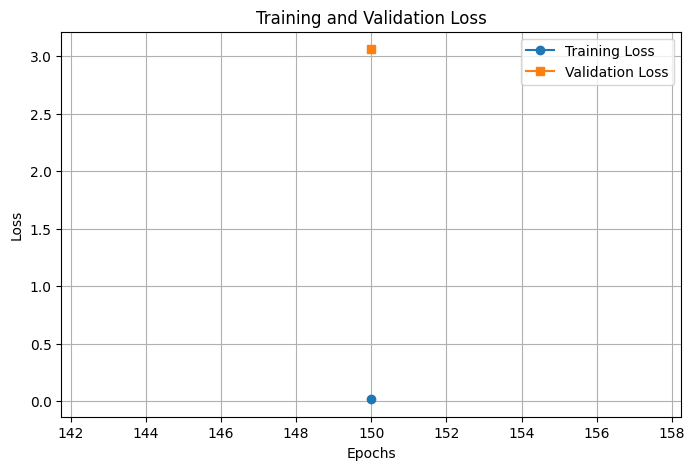

In [ ]:

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_loss, label='Training Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='s')


plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True) 

plt.show()